In [1]:
import os
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import omicverse as ov
import scvi
from scvi.model.utils import mde

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2


   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

Version: 1.5.3, Tutorials: https://omicverse.readthedocs.io/


[rank: 0] Global seed set to 0


In [2]:
sc.settings.set_figure_params(dpi=100, frameon=False)
sc.set_figure_params(dpi=100)
sc.set_figure_params(figsize=(3, 3))
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (3, 3)


In [3]:
# Change the working directory to the Garfield folder (if needed)
os.chdir('/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/code/20250725_cross-species_integration_v3')
os.getcwd()

'/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/code/20250725_cross-species_integration_v3'

In [4]:
# Load dataset
adata = sc.read('human_monkey_20250725.h5ad')
adata

AnnData object with n_obs × n_vars = 176364 × 85305
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage', 'Unintegrated_res_0.5'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Unintegrated_res_0.5_colors', 'hvg', 'leiden', 'lineage_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'pca', 'scANVI_res_0.5_colors', 'species_colors', 'stage_colors', 'umap'
    obsm: 'Unintegrated', 'X_Unintegrated', 'X_pca', 'X_scANVI', 'X_umap', 'scANVI', 'scVI'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [5]:
import re
import pandas as pd

# 定义去后缀函数
def remove_trailing_number(s):
    return re.sub(r'_\d+$', '', s)

# 清洗 reanno 的函数
def clean_reanno(adata):
    """
    清洗 AnnData 对象中的 adata.obs['reanno'] 注释，并生成 brief_reanno。
    """
    # 1. 添加临时列，保存原始的 reanno
    adata.obs['original_reanno'] = adata.obs['reanno'].copy()
    
    # 2. 定义替换逻辑
    def replace_reanno(x):
        # 固定字符串替换
        x = x.replace("Ectodrm", "Ectoderm")
        x = x.replace("Amniontic.ectoderm", "Amnion")
        x = x.replace("Cardiac.myocyte", "Cardiac.mesoderm")
        x = x.replace("Neural.ectoderm.fore_midbrain", "Neural.ectoderm.brain")
        x = x.replace("Amniontic.epi", "Amniotic.epi")

        # 正则替换
        x = re.sub(r"Neuromesodermal\.progenitor", "NMP", x)
        x = re.sub(r"Myocyte\.progenitor", "Rostral.mesoderm", x)
        x = re.sub(r"Neural\.ectoderm\.(fore|mid|hind)brain", "Neural.ectoderm.brain", x)
        
        # 替换 VE（只替换完全匹配项）
        if x == "VE":
            x = "VE/YE"

        # 去除尾部数字（如 'STB_1' -> 'STB'）
        x = remove_trailing_number(x)
        
        return x

    # 3. 应用替换函数，生成 brief_reanno
    adata.obs['brief_reanno'] = adata.obs['reanno'].apply(replace_reanno)
    
    # 4. 删除临时列 original_reanno
    adata.obs.drop(columns=['original_reanno'], inplace=True)
    
    return adata

adata = clean_reanno(adata)

In [6]:
adata

AnnData object with n_obs × n_vars = 176364 × 85305
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sample', 'stage', 'percent.mt', 'species', 'embryo', 'platform', 'orig_anno', 'orig_sub_anno', 'harmo.anno', 'doublet', 'doublet_score', 'scANVI_res_0.5', 'leiden_3', 'reanno', 'combined_annotation', 'unicorns', 'lineage', 'Unintegrated_res_0.5', 'brief_reanno'
    var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection'
    uns: 'Unintegrated_res_0.5_colors', 'hvg', 'leiden', 'lineage_colors', 'log1p', 'neighbors', 'orig.ident_colors', 'pca', 'scANVI_res_0.5_colors', 'species_colors', 'stage_colors', 'umap'
    obsm: 'Unintegrated', 'X_Unintegrated', 'X_pca', 'X_scANVI', 'X_umap', 'scANVI', 'scVI'
    varm: 'PCs'
    layers: 'counts', 'logcounts'
    obsp: 'connectivities', 'distances'

In [7]:
print(adata.obs[['reanno', 'brief_reanno']].head())

                                     reanno brief_reanno
AAACCTGAGACGCTTT-1_1_1_1_1_1_1        EVT_1          EVT
AACGTTGAGACGCAAC-1_1_1_1_1_1_1        STB_3          STB
AACTCAGCAGACGCCT-1_1_1_1_1_1_1        STB_2          STB
AAGACCTTCGGCGCTA-1_1_1_1_1_1_1        CTB_2          CTB
AAGCCGCCATATGGTC-1_1_1_1_1_1_1  Hypoblast_2    Hypoblast


In [ ]:
# Step 1: calculate hvg
sc.pp.highly_variable_genes(adata, n_top_genes=2000, flavor="cell_ranger", batch_key="orig.ident")

# subset data use HVG
adata_hvg = adata[:, adata.var['highly_variable']]


In [ ]:
# Step 2: seperate human and monkey data
adata_human = adata_hvg[adata_hvg.obs['species'] == 'Homo sapiens'].copy()
adata_monkey = adata_hvg[adata_hvg.obs['species'] == 'Macaca fascicularis'].copy()

# Step 3: define function for calculating average expression by reanno
def compute_average_expression(adata, cell_type_key='reanno'):
    """
    calculate average expression of hvgs
    return：DataFrame，index=cell_type，columns=genes
    """
    cell_types = adata.obs[cell_type_key].unique()
    avg_expr = []

    for ct in cell_types:
        cell_data = adata[adata.obs[cell_type_key] == ct]
        avg = cell_data.X.mean(axis=0)
        if isinstance(avg, np.matrix):
            avg = np.array(avg).flatten()
        avg_expr.append(avg)

    avg_df = pd.DataFrame(np.array(avg_expr), index=cell_types, columns=adata.var_names)
    return avg_df

# Step 4: calculate average expression for each specie
human_avg = compute_average_expression(adata_human, 'reanno')
monkey_avg = compute_average_expression(adata_monkey, 'reanno')

# Step 5: print out results
print(f"Number of HVGs: {adata_hvg.n_vars}")
print(f"Human cell types: {len(human_avg)}")
print(f"Monkey cell types: {len(monkey_avg)}")
print("\nHuman average expression (first 2 cell types):")
print(human_avg.head(2))
print("\nMonkey average expression (first 2 cell types):")
print(monkey_avg.head(2))

Number of HVGs: 2000
Human cell types: 48
Monkey cell types: 55

Human average expression (first 2 cell types):
            A2M     AADAT      AASS     ABCA1    ABCB11     ABCC4     ABCG2  \
EVT_1  0.001234  0.073741  0.115911  0.012000  0.001008  0.055775  0.627942   
STB_3  0.000880  0.290191  0.037369  0.010207  0.002022  0.007997  0.606169   

        ABHD17C    ABI3BP    ABLIM1  ...    ZNF521   ZNF608        ZNF679  \
EVT_1  0.088052  0.006682  0.006210  ...  0.002928  0.02904  6.957342e-07   
STB_3  0.197155  0.022885  0.004808  ...  0.002588  0.00389  4.385059e-04   

         ZNF703    ZNF750   ZNF804A   ZNF804B   ZSCAN10    ZSCAN4    ZYG11A  
EVT_1  0.045803  0.033907  0.005821  0.000988  0.006881  0.002082  0.073171  
STB_3  0.526550  0.089588  0.003700  0.001615  0.004803  0.017770  0.038286  

[2 rows x 2000 columns]

Monkey average expression (first 2 cell types):
                            A2M     AADAT      AASS     ABCA1    ABCB11  \
Allantois              0.484029  0.

In [10]:
# 4. Compute Correlation Matrix
correlation_matrix = pd.DataFrame(
    index=human_avg.index,
    columns=monkey_avg.index,
    dtype=float
)

# Compute Pearson correlation between each pair of cell types
for human_cell_type in human_avg.index:
    for monkey_cell_type in monkey_avg.index:
        human_profile = human_avg.loc[human_cell_type]
        monkey_profile = monkey_avg.loc[monkey_cell_type]
        corr_coef = human_profile.corr(monkey_profile, method='pearson')
        correlation_matrix.loc[human_cell_type, monkey_cell_type] = corr_coef

# Ensure no NaN or infinite values in the correlation matrix
correlation_matrix = correlation_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)


<Figure size 2000x1500 with 0 Axes>

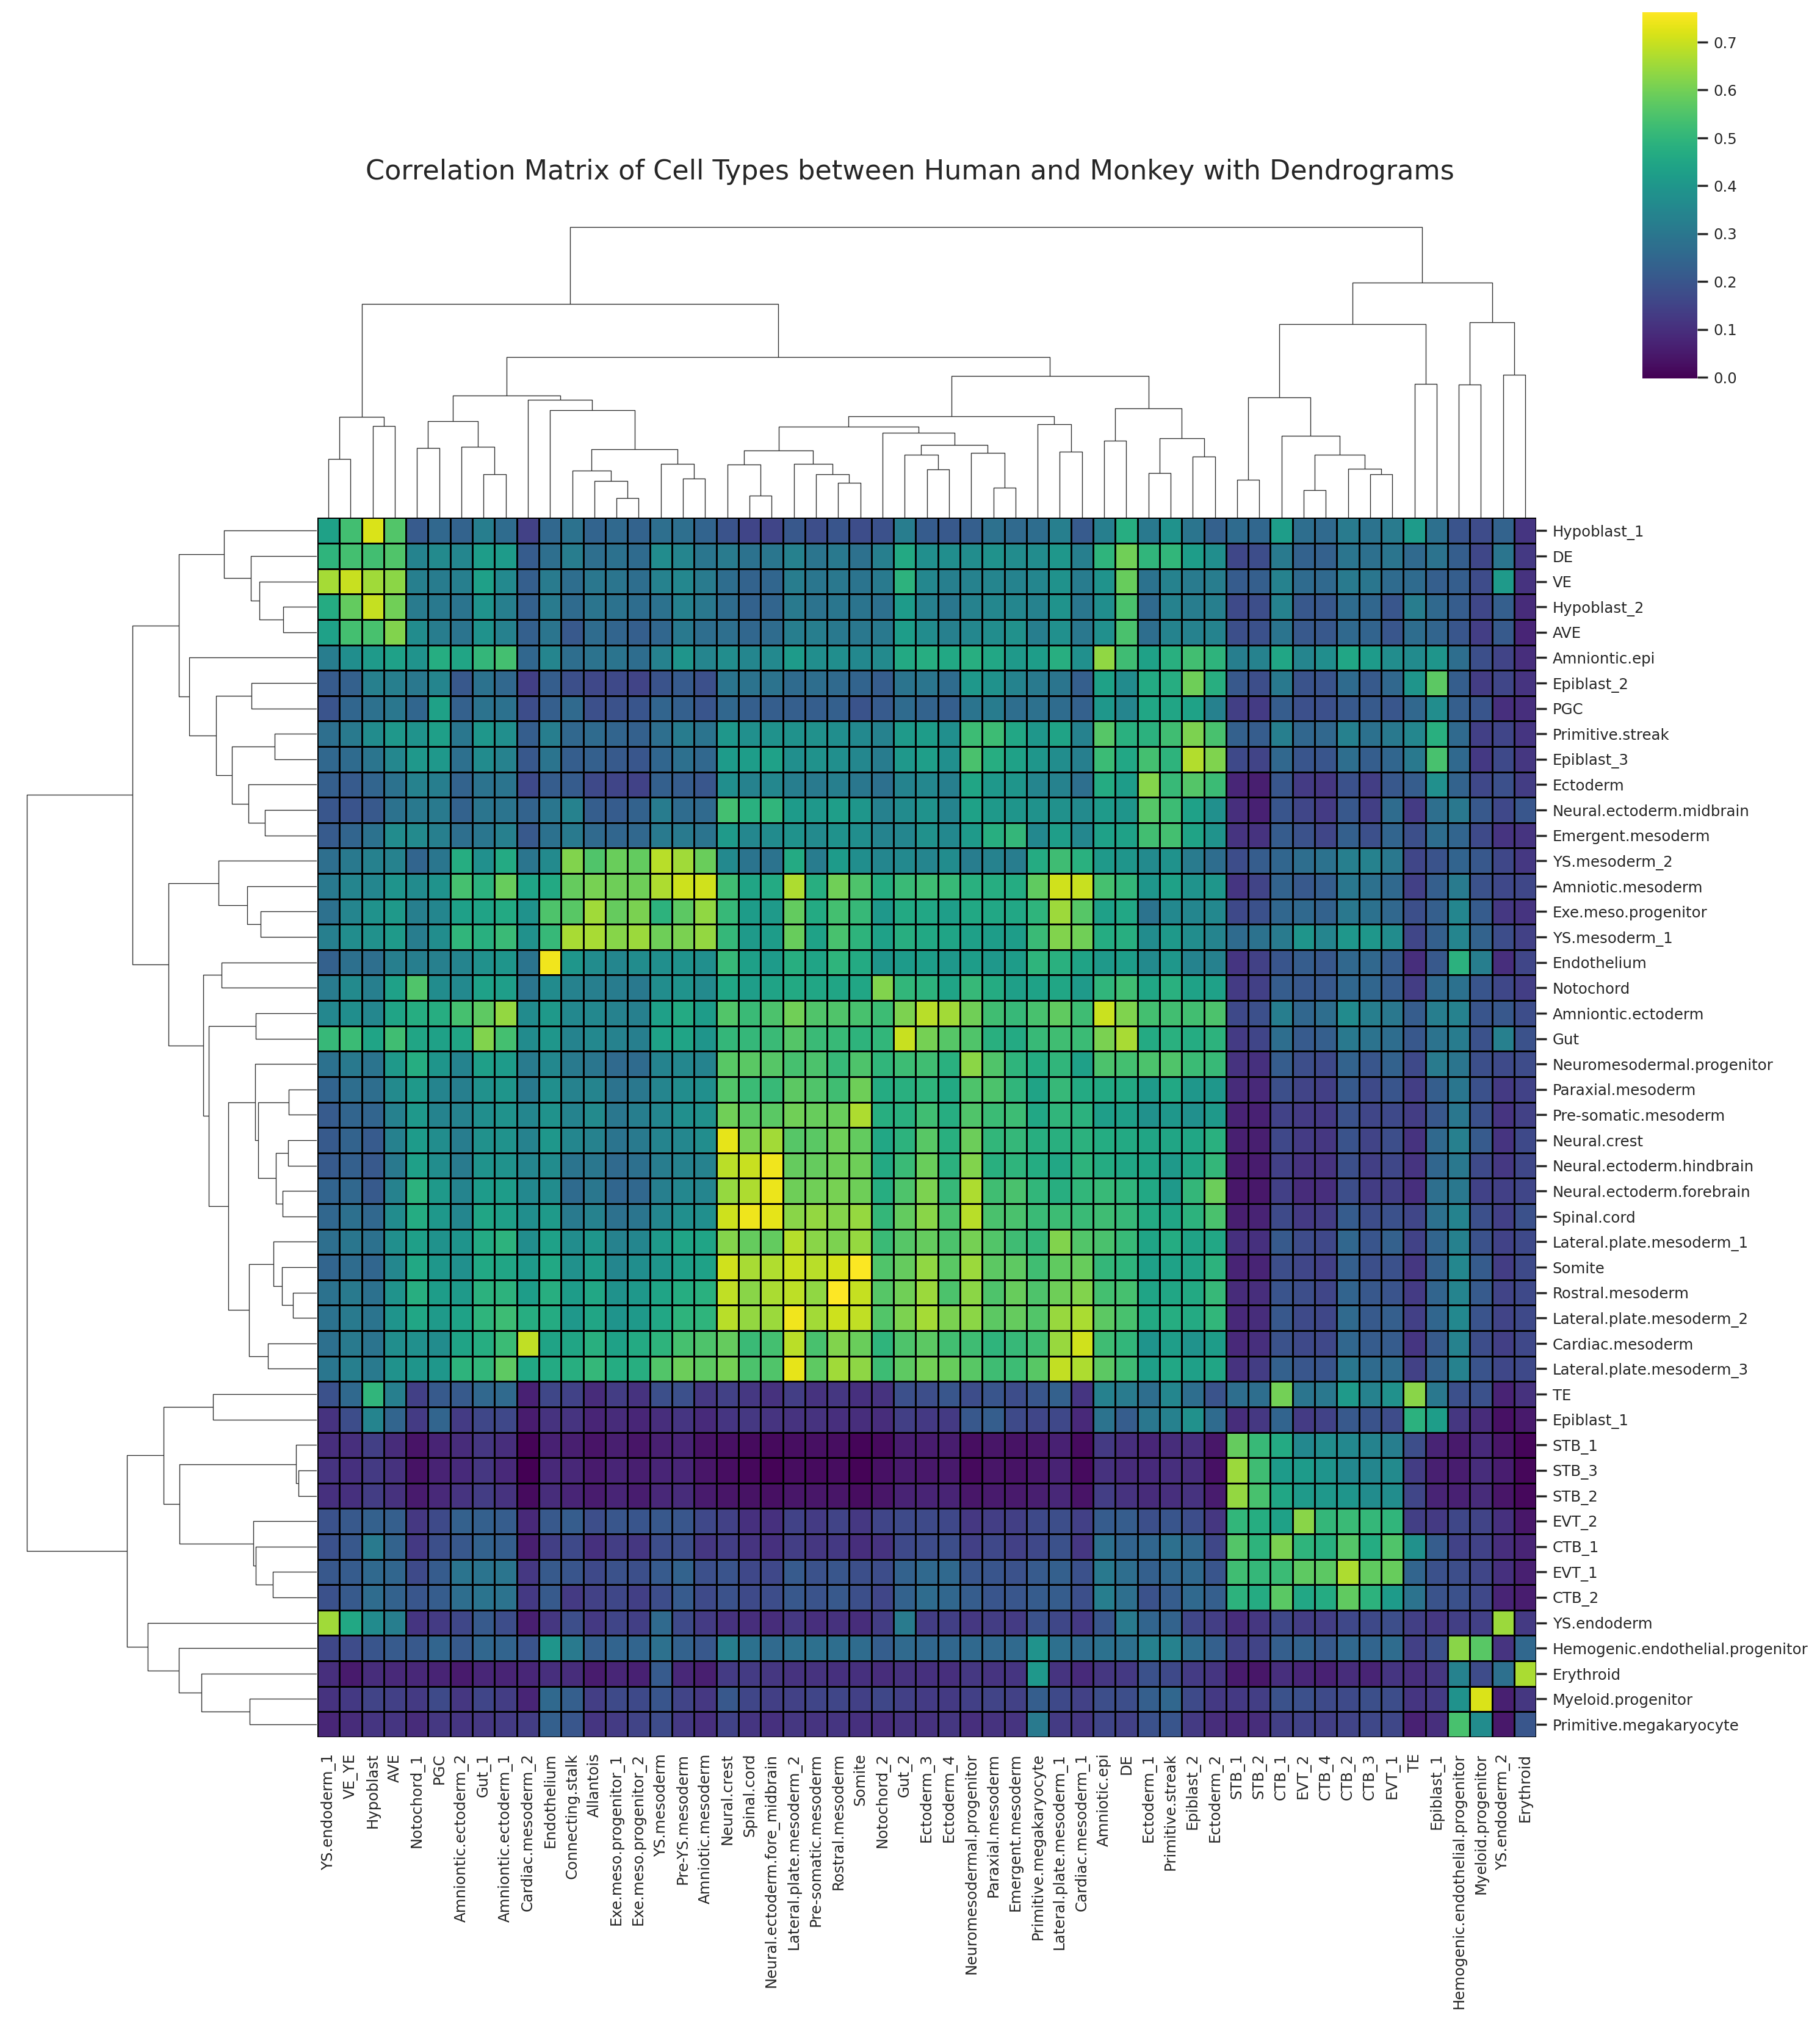

In [11]:
# 5. Plot Correlation Matrix with Dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['pdf.fonttype'] = 42  # Ensures that fonts are saved as text, not outlines
plt.rcParams['font.sans-serif'] = ['Arial']  # Use Arial or another common font

plt.figure(figsize=(20, 15))
sns.set(font_scale=0.8)

g = sns.clustermap(correlation_matrix, 
                   annot=False,
                   fmt=".2f", 
                   cmap='viridis',
                   xticklabels=monkey_avg.index,
                   yticklabels=human_avg.index,
                   figsize=(15, 15),
                   dendrogram_ratio=(0.2, 0.2),
                   cbar_pos=(0.9, 0.9, 0.03, 0.2),
                   linewidths=0.5,
                   linecolor='black')

plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)

g.fig.suptitle('Correlation Matrix of Cell Types between Human and Monkey with Dendrograms', 
               fontsize=16, y=1.02)

plt.show()
# Export the plot as a PDF and PNG
g.fig.savefig('correlation_matrix_dendrogram.pdf', dpi=300, bbox_inches='tight')

In [ ]:
# define function to calculate average expression
def compute_average_expression(adata, cell_type_key='reanno'):
    """
    calculate average expression for reanno groups
    return：DataFrame，index=cell_type，columns=genes
    """
    cell_types = adata.obs[cell_type_key].unique()
    avg_expr = []

    for ct in cell_types:
        cell_data = adata[adata.obs[cell_type_key] == ct]
        avg = cell_data.X.mean(axis=0)
        if isinstance(avg, np.matrix):
            avg = np.array(avg).flatten()
        avg_expr.append(avg)

    avg_df = pd.DataFrame(np.array(avg_expr), index=cell_types, columns=adata.var_names)
    return avg_df

#compute correlation based on all genes
# Step 2: separate human and monkey data
adata_human = adata[adata.obs['species'] == 'Homo sapiens'].copy()
adata_monkey = adata[adata.obs['species'] == 'Macaca fascicularis'].copy()

# Step 4: calculate average expression for each specie
human_avg = compute_average_expression(adata_human, 'reanno')
monkey_avg = compute_average_expression(adata_monkey, 'reanno')

# Step 5: print out results
print(f"Human cell types: {len(human_avg)}")
print(f"Monkey cell types: {len(monkey_avg)}")
print("\nHuman average expression (first 2 cell types):")
print(human_avg.head(2))
print("\nMonkey average expression (first 2 cell types):")
print(monkey_avg.head(2))


Human cell types: 48
Monkey cell types: 55

Human average expression (first 2 cell types):
       1-Sep  10-Mar  11-Mar  12-Sep  14-Sep  2-Sep  3-Sep  4-Mar  4-Sep  \
EVT_1    0.0     0.0     0.0     0.0     0.0    0.0    0.0    0.0    0.0   
STB_3    0.0     0.0     0.0     0.0     0.0    0.0    0.0    0.0    0.0   

       5-8S-rRNA  ...    ZWILCH     ZWINT      ZXDA      ZXDB      ZXDC  \
EVT_1        0.0  ...  0.158686  0.552644  0.005535  0.011702  0.191150   
STB_3        0.0  ...  0.072418  0.146454  0.001395  0.007810  0.085518   

         ZYG11A    ZYG11B       ZYX     ZZEF1      ZZZ3  
EVT_1  0.073171  0.292272  0.163825  0.170893  0.008913  
STB_3  0.038286  0.090563  0.169503  0.181115  0.022732  

[2 rows x 85305 columns]

Monkey average expression (first 2 cell types):
                          1-Sep    10-Mar    11-Mar    12-Sep    14-Sep  \
Allantois              0.000367  0.000277  0.000011  0.000062  0.000093   
Exe.meso.progenitor_1  0.000461  0.000000  0.000000  0.

In [13]:
set(adata.obs['reanno'])

{'AVE',
 'Allantois',
 'Amniontic.ectoderm',
 'Amniontic.ectoderm_1',
 'Amniontic.ectoderm_2',
 'Amniontic.epi',
 'Amniotic.epi',
 'Amniotic.mesoderm',
 'CTB_1',
 'CTB_2',
 'CTB_3',
 'CTB_4',
 'Cardiac.mesoderm',
 'Cardiac.mesoderm_1',
 'Cardiac.mesoderm_2',
 'Connecting.stalk',
 'DE',
 'EVT_1',
 'EVT_2',
 'Ectoderm',
 'Ectoderm_1',
 'Ectoderm_2',
 'Ectoderm_3',
 'Ectoderm_4',
 'Emergent.mesoderm',
 'Endothelium',
 'Epiblast_1',
 'Epiblast_2',
 'Epiblast_3',
 'Erythroid',
 'Exe.meso.progenitor',
 'Exe.meso.progenitor_1',
 'Exe.meso.progenitor_2',
 'Gut',
 'Gut_1',
 'Gut_2',
 'Hemogenic.endothelial.progenitor',
 'Hypoblast',
 'Hypoblast_1',
 'Hypoblast_2',
 'Lateral.plate.mesoderm_1',
 'Lateral.plate.mesoderm_2',
 'Lateral.plate.mesoderm_3',
 'Myeloid.progenitor',
 'Neural.crest',
 'Neural.ectoderm.fore_midbrain',
 'Neural.ectoderm.forebrain',
 'Neural.ectoderm.hindbrain',
 'Neural.ectoderm.midbrain',
 'Neuromesodermal.progenitor',
 'Notochord',
 'Notochord_1',
 'Notochord_2',
 'PGC',
 

In [14]:
adata_human.obs['reanno'].unique()

['EVT_1', 'STB_3', 'STB_2', 'CTB_2', 'Hypoblast_2', ..., 'YS.endoderm', 'Emergent.mesoderm', 'Ectoderm', 'TE', 'Epiblast_1']
Length: 48
Categories (48, object): ['AVE', 'Amniontic.ectoderm', 'Amniontic.epi', 'Amniotic.mesoderm', ..., 'VE', 'YS.endoderm', 'YS.mesoderm_1', 'YS.mesoderm_2']

In [15]:
adata_monkey.obs['reanno'].unique()

['Allantois', 'Exe.meso.progenitor_1', 'Gut_1', 'Amniotic.epi', 'Epiblast_2', ..., 'Ectoderm_4', 'Pre-somatic.mesoderm', 'Notochord_2', 'Exe.meso.progenitor_2', 'CTB_4']
Length: 55
Categories (55, object): ['AVE', 'Allantois', 'Amniontic.ectoderm_1', 'Amniontic.ectoderm_2', ..., 'VE_YE', 'YS.endoderm_1', 'YS.endoderm_2', 'YS.mesoderm']

In [16]:
# Check if any row has zero variance
print((human_avg.var(axis=1) == 0).sum())
print((monkey_avg.var(axis=1) == 0).sum())

0
0


In [17]:
print(human_avg.isna().sum().sum())
print(monkey_avg.isna().sum().sum())

0
0


In [18]:
# 4. Compute Correlation Matrix
correlation_matrix = pd.DataFrame(
    index=human_avg.index,
    columns=monkey_avg.index,
    dtype=float
)

# Compute Pearson correlation between each pair of cell types
for human_cell_type in human_avg.index:
    for monkey_cell_type in monkey_avg.index:
        human_profile = human_avg.loc[human_cell_type]
        monkey_profile = monkey_avg.loc[monkey_cell_type]
        corr_coef = human_profile.corr(monkey_profile, method='pearson')
        correlation_matrix.loc[human_cell_type, monkey_cell_type] = corr_coef

# Ensure no NaN or infinite values in the correlation matrix
correlation_matrix = correlation_matrix.replace([np.inf, -np.inf], np.nan).fillna(0)


<Figure size 2000x1500 with 0 Axes>

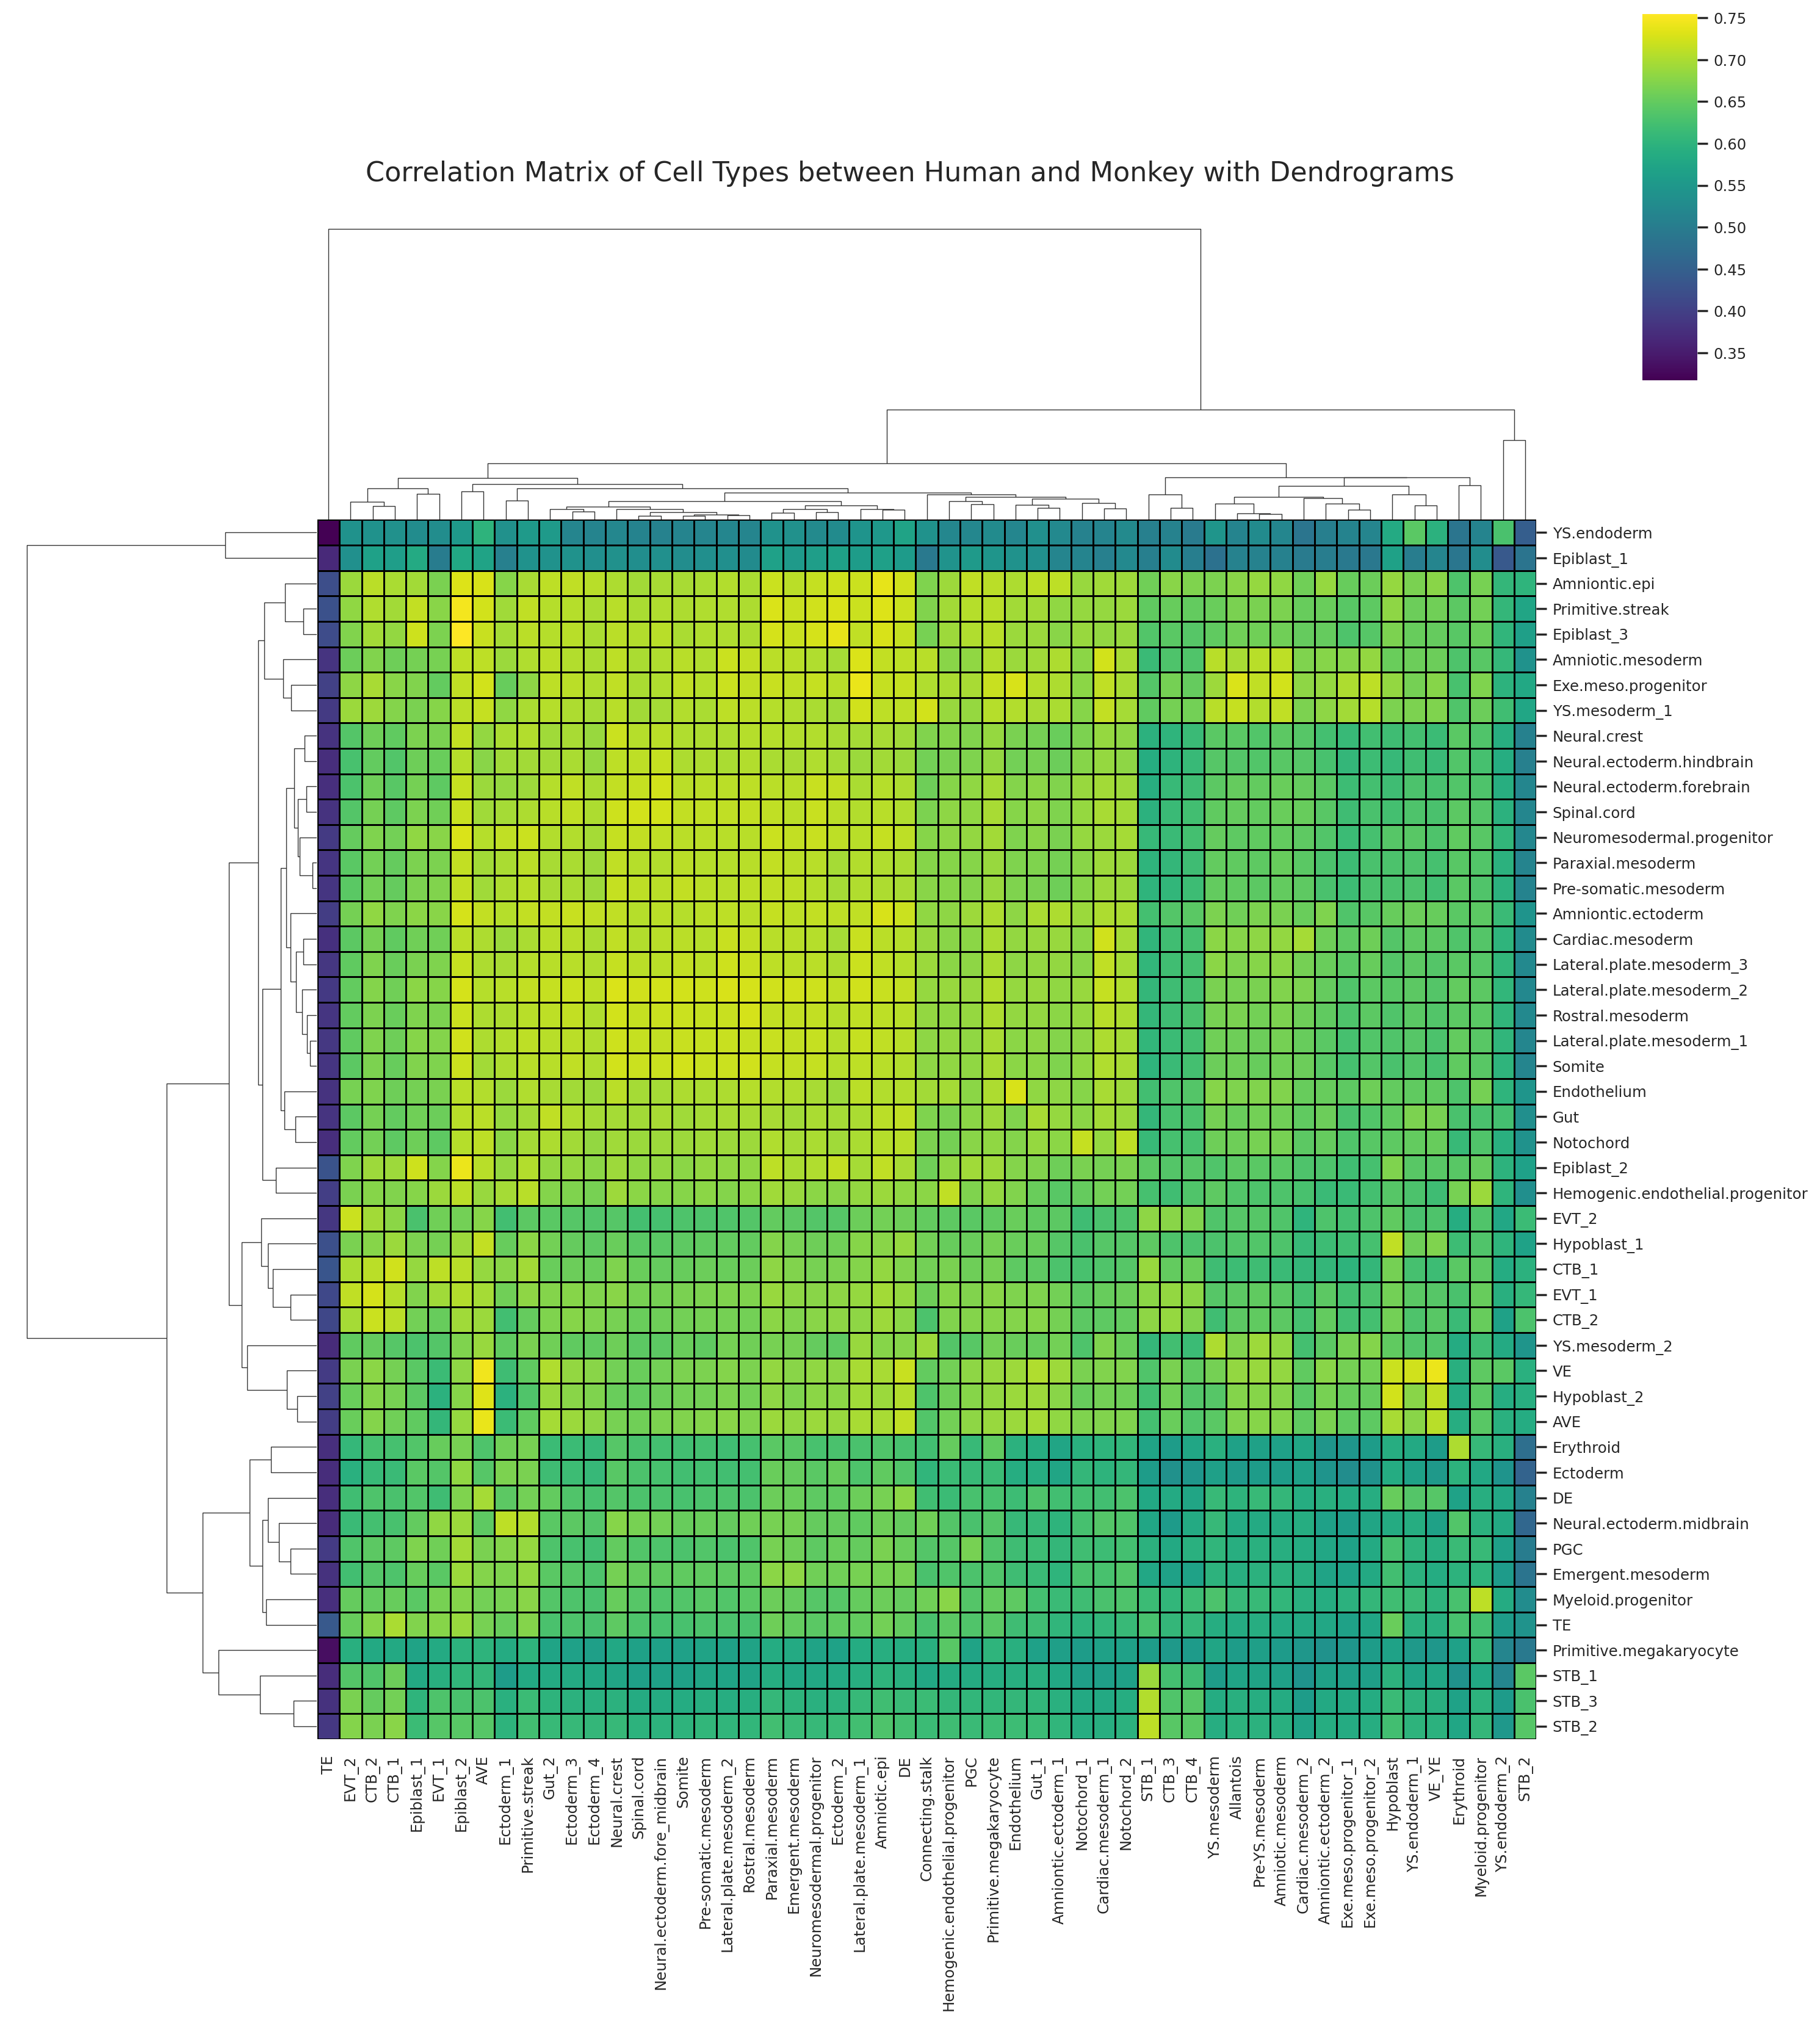

In [19]:
# 5. Plot Correlation Matrix with Dendrogram
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['pdf.fonttype'] = 42  # Ensures that fonts are saved as text, not outlines
plt.rcParams['font.sans-serif'] = ['Arial']  # Use Arial or another common font

plt.figure(figsize=(20, 15))
sns.set(font_scale=0.8)

g = sns.clustermap(correlation_matrix, 
                   annot=False,
                   fmt=".2f", 
                   cmap='viridis',
                   xticklabels=monkey_avg.index,
                   yticklabels=human_avg.index,
                   figsize=(15, 15),
                   dendrogram_ratio=(0.2, 0.2),
                   cbar_pos=(0.9, 0.9, 0.03, 0.2),
                   linewidths=0.5,
                   linecolor='black')

plt.setp(g.ax_heatmap.xaxis.get_majorticklabels(), rotation=90)
plt.setp(g.ax_heatmap.yaxis.get_majorticklabels(), rotation=0)

g.fig.suptitle('Correlation Matrix of Cell Types between Human and Monkey with Dendrograms', 
               fontsize=16, y=1.02)

plt.show()
# Export the plot as a PDF and PNG
g.fig.savefig('correlation_matrix_dendrogram_allgenes.pdf', dpi=300, bbox_inches='tight')

In [ ]:

# load marker gene data
human_marker_path = "/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/data/human_full_marker_gene_table.csv"
monkey_marker_path = "/storage2/liuxiaodongLab/fanxueying/embryo_benchmarking_rebuttal/data/monkey_full_marker_gene_table.csv"

human_markers = pd.read_csv(human_marker_path)
monkey_markers = pd.read_csv(monkey_marker_path)

# Step 5: filter marker（pval_adj < 0.05 & logfoldchange > 2）
human_sig = human_markers[(human_markers['pval_adj'] < 0.05) & (human_markers['logfoldchange'] > 2)]
monkey_sig = monkey_markers[(monkey_markers['pval_adj'] < 0.05) & (monkey_markers['logfoldchange'] > 2)]

# Step 6: creates dictionaries to map cell type names to the sets of marker genes
human_celltype_to_genes = {
    ct: set(group['gene'].unique())
    for ct, group in human_sig.groupby('cluster')
}

monkey_celltype_to_genes = {
    ct: set(group['gene'].unique())
    for ct, group in monkey_sig.groupby('cluster')
}

# Step 7: remove tailing
def remove_trailing_number(s):
    return re.sub(r'_\d+$', '', s)

# Pair-wise overlap + Jaccard index
results = []

for h_ct, h_genes in human_celltype_to_genes.items():
    for m_ct, m_genes in monkey_celltype_to_genes.items():
        intersection = h_genes.intersection(m_genes)
        union = h_genes.union(m_genes)
        jaccard = len(intersection) / len(union) if len(union) > 0 else 0
        results.append({
            'human_celltype': h_ct,
            'monkey_celltype': m_ct,
            'brief_human': remove_trailing_number(h_ct),
            'brief_monkey': remove_trailing_number(m_ct),
            'common_marker_count': len(intersection),
            'jaccard_index': round(jaccard, 4)
        })

overlap_df = pd.DataFrame(results)

In [ ]:
# Step 1: easure correlation_matrix was calculated previously and is in DataFrame format

# Step 2: convert correlation_matrix（pair-wise）to long format
correlation_pairs = []
for h_ct in correlation_matrix.index:
    for m_ct in correlation_matrix.columns:
        correlation_pairs.append({
            'human_celltype': h_ct,
            'monkey_celltype': m_ct,
            'correlation': correlation_matrix.loc[h_ct, m_ct]
        })

correlation_df = pd.DataFrame(correlation_pairs)



In [23]:
correlation_df

,human_celltype,monkey_celltype,correlation
0,EVT_1,Allantois,0.644490
1,EVT_1,Exe.meso.progenitor_1,0.623837
2,EVT_1,Gut_1,0.670120
3,EVT_1,Amniotic.epi,0.694688
4,EVT_1,Epiblast_2,0.703713
...,...,...,...
2635,Epiblast_1,Ectoderm_4,0.533254
2636,Epiblast_1,Pre-somatic.mesoderm,0.533658
2637,Epiblast_1,Notochord_2,0.522890
2638,Epiblast_1,Exe.meso.progenitor_2,0.492122


In [24]:
output_path = "human_monkey_jaccard.csv"
overlap_df.to_csv(output_path, index=False)

output_path = "human_monkey_correlation.csv"
correlation_df.to_csv(output_path, index=False)

# Check unique values in human_celltype and monkey_celltype for both DataFrames
print("Unique human_celltype in overlap_df:", overlap_df['human_celltype'].unique())
print("Unique human_celltype in correlation_df:", correlation_df['human_celltype'].unique())
print("\nUnique monkey_celltype in overlap_df:", overlap_df['monkey_celltype'].unique())
print("Unique monkey_celltype in correlation_df:", correlation_df['monkey_celltype'].unique())

Unique human_celltype in overlap_df: ['AVE' 'Amniontic.ectoderm' 'Amniontic.epi' 'Amniotic.mesoderm' 'CTB_1'
 'CTB_2' 'Cardiac.mesoderm' 'DE' 'EVT_1' 'EVT_2' 'Ectoderm'
 'Emergent.mesoderm' 'Endothelium' 'Epiblast_1' 'Epiblast_2' 'Epiblast_3'
 'Erythroid' 'Exe.meso.progenitor' 'Gut'
 'Hemogenic.endothelial.progenitor' 'Hypoblast_1' 'Hypoblast_2'
 'Lateral.plate.mesoderm_1' 'Lateral.plate.mesoderm_2'
 'Lateral.plate.mesoderm_3' 'Myeloid.progenitor' 'Neural.crest'
 'Neural.ectoderm.forebrain' 'Neural.ectoderm.hindbrain'
 'Neural.ectoderm.midbrain' 'Neuromesodermal.progenitor' 'Notochord' 'PGC'
 'Paraxial.mesoderm' 'Pre-somatic.mesoderm' 'Primitive.megakaryocyte'
 'Primitive.streak' 'Rostral.mesoderm' 'STB_1' 'STB_2' 'STB_3' 'Somite'
 'Spinal.cord' 'TE' 'VE' 'YS.endoderm' 'YS.mesoderm_1' 'YS.mesoderm_2']
Unique human_celltype in correlation_df: ['EVT_1' 'STB_3' 'STB_2' 'CTB_2' 'Hypoblast_2' 'Epiblast_2' 'STB_1'
 'EVT_2' 'CTB_1' 'Exe.meso.progenitor' 'Primitive.streak' 'AVE'
 'Hypoblast_1'

In [ ]:
cell_type_mapping = {
    # human_celltype mapping
    'Neural.ectoderm.forebrain': 'Neural.ectoderm.brain',
    'Neural.ectoderm.hindbrain': 'Neural.ectoderm.brain',
    'Neural.ectoderm.midbrain': 'Neural.ectoderm.brain',
    'VE': 'VE_YE',

    # add other correction if necessary
}

In [ ]:
# Step 3: combine correlation and jaccard
combined_df = pd.merge(
    overlap_df,
    correlation_df,
    on=['human_celltype', 'monkey_celltype'],
    how='outer'
)

# Step 4: rename brief column to avoid confusing (optional)
combined_df.rename(columns={'brief_human': 'human_brief', 'brief_monkey': 'monkey_brief'}, inplace=True)

# Step 5: save as CSV
output_path = "human_monkey_correlation_jaccard.csv"
combined_df.to_csv(output_path, index=False)

# Step 6: export logging
print(f"combined DataFrame was saved to: {output_path}")
print("\n the first few rows：")
print(combined_df.head())

合并后的 DataFrame 已保存到: human_monkey_correlation_jaccard.csv

前几行预览：
  human_celltype       monkey_celltype human_brief        monkey_brief  \
0            AVE                   AVE         AVE                 AVE   
1            AVE             Allantois         AVE           Allantois   
2            AVE  Amniontic.ectoderm_1         AVE  Amniontic.ectoderm   
3            AVE  Amniontic.ectoderm_2         AVE  Amniontic.ectoderm   
4            AVE          Amniotic.epi         AVE        Amniotic.epi   

   common_marker_count  jaccard_index  correlation  
0                  174         0.0473     0.740443  
1                   45         0.0242     0.672060  
2                   36         0.0205     0.682626  
3                   51         0.0267     0.666995  
4                   25         0.0149     0.697094  


In [27]:
print(combined_df.isna().sum().sum())

0


In [28]:
combined_df

,human_celltype,monkey_celltype,human_brief,monkey_brief,common_marker_count,jaccard_index,correlation
0,AVE,AVE,AVE,AVE,174,0.0473,0.740443
1,AVE,Allantois,AVE,Allantois,45,0.0242,0.672060
2,AVE,Amniontic.ectoderm_1,AVE,Amniontic.ectoderm,36,0.0205,0.682626
3,AVE,Amniontic.ectoderm_2,AVE,Amniontic.ectoderm,51,0.0267,0.666995
4,AVE,Amniotic.epi,AVE,Amniotic.epi,25,0.0149,0.697094
...,...,...,...,...,...,...,...
2635,YS.mesoderm_2,TE,YS.mesoderm,TE,35,0.0046,0.370906
2636,YS.mesoderm_2,VE_YE,YS.mesoderm,VE_YE,24,0.0148,0.636759
2637,YS.mesoderm_2,YS.endoderm_1,YS.mesoderm,YS.endoderm,17,0.0096,0.635598
2638,YS.mesoderm_2,YS.endoderm_2,YS.mesoderm,YS.endoderm,12,0.0077,0.583406


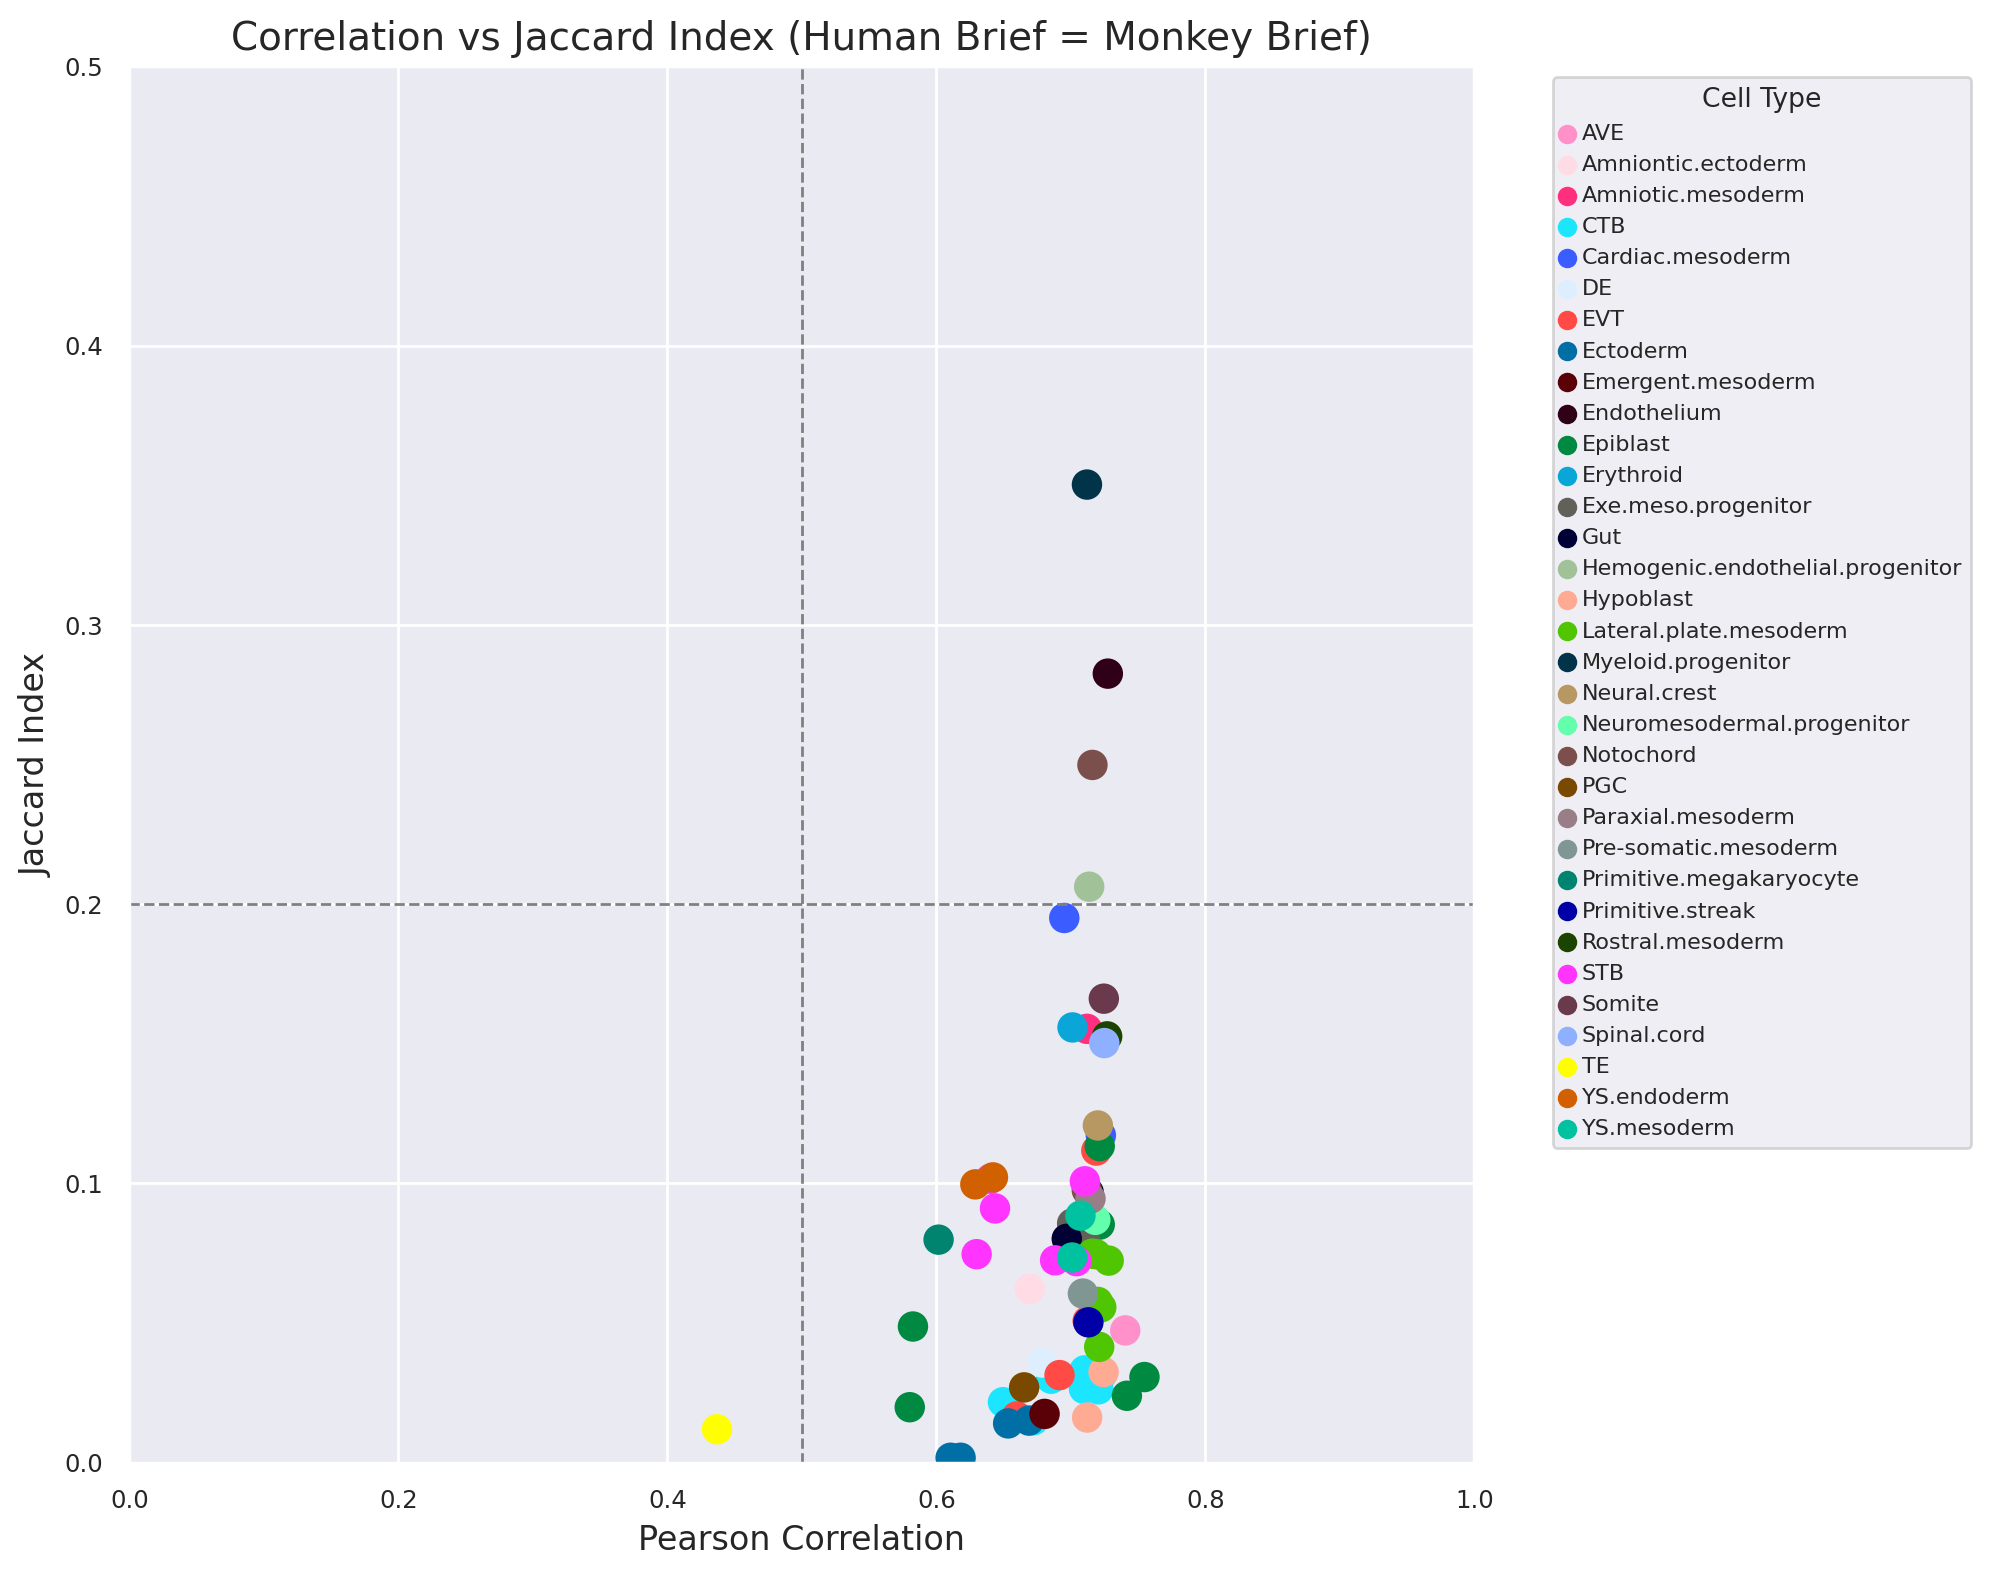

匹配结果已保存到: human_monkey_matched_correlation_jaccard.csv


In [ ]:
# Step 6: assign colors

godsnot_102 = [
    "#FFFF00", "#1CE6FF", "#FF34FF", "#FF4A46", "#008941", "#006FA6", "#A30059",
    "#FFDBE5", "#7A4900", "#0000A6", "#63FFAC", "#B79762", "#004D43", "#8FB0FF",
    "#997D87", "#5A0007", "#809693", "#6A3A4C", "#1B4400", "#4FC601", "#3B5DFF",
    "#4A3B53", "#FF2F80", "#61615A", "#BA0900", "#6B7900", "#00C2A0", "#FFAA92",
    "#FF90C9", "#B903AA", "#D16100", "#DDEFFF", "#000035", "#7B4F4B", "#A1C299",
    "#300018", "#0AA6D8", "#013349", "#00846F", "#372101", "#FFB500", "#C2FFED",
    "#A079BF", "#CC0744", "#C0B9B2", "#C2FF99", "#001E09", "#00489C", "#6F0062",
    "#0CBD66", "#EEC3FF", "#456D75", "#B77B68", "#7A87A1", "#788D66", "#885578",
    "#FAD09F", "#FF8A9A", "#D157A0", "#BEC459", "#456648", "#0086ED", "#886F4C",
    "#34362D", "#B4A8BD", "#00A6AA", "#452C2C", "#636375", "#A3C8C9", "#FF913F",
    "#938A81", "#575329", "#00FECF", "#B05B6F", "#8CD0FF", "#3B9700", "#04F757",
    "#C8A1A1", "#1E6E00", "#7900D7", "#A77500", "#6367A9", "#A05837", "#6B002C",
    "#772600", "#D790FF", "#99ADC0", "#3A2465", "#922329", "#5B4534", "#FDE8DC",
    "#404E55", "#0089A3", "#CB7E98", "#A4E804", "#324E72"
]

crossspecies_labels = [
            "TE", "CTB", "STB","EVT",
            "Epiblast", "Ectoderm" ,
            "Amniotic.epi" , "Amniontic.ectoderm",
            "PGC" ,
            "Primitive.streak",
            "Neuromesodermal.progenitor" ,
            "Neural.crest" ,"Neural.ectoderm.brain","Spinal.cord", 
            "Paraxial.mesoderm", "Emergent.mesoderm", "Pre-somatic.mesoderm" , "Somite", "Rostral.mesoderm",
            "Lateral.plate.mesoderm","Cardiac.mesoderm" ,"Connecting.stalk","Amniotic.mesoderm" ,"Exe.meso.progenitor","Allantois","Pre-YS.mesoderm", "YS.mesoderm",
            "Hypoblast", "AVE","VE_YE","YS.endoderm" ,
            "DE", "Gut", 
            "Notochord" , 
            "Hemogenic.endothelial.progenitor","Endothelium","Erythroid","Myeloid.progenitor" , "Primitive.megakaryocyte"
]

# assign colors
cell_type_to_color = dict(zip(crossspecies_labels, godsnot_102[:len(crossspecies_labels)]))
color_palette = cell_type_to_color

# Step 5: only keep human_brief == monkey_brief
matched_df = combined_df[combined_df['human_brief'] == combined_df['monkey_brief']].copy()
matched_df = matched_df.reset_index(drop=True)


# Step 7: plot
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=matched_df,
    x='correlation',
    y='jaccard_index',
    hue='human_brief',          
    palette=color_palette,
    s=120,
    edgecolor='none',
    alpha=1.0,
    linewidth=0
)

# set title and axis
plt.title("Correlation vs Jaccard Index (Human Brief = Monkey Brief)", fontsize=14)
plt.xlabel("Pearson Correlation", fontsize=12)
plt.ylabel("Jaccard Index", fontsize=12)

plt.xlim(0, 1)
plt.ylim(0, 0.5)

plt.axhline(y=0.2, color='gray', linestyle='--', linewidth=1)
plt.axvline(x=0.5, color='gray', linestyle='--', linewidth=1)

# set legend
plt.legend(title="Cell Type", bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

# layout
plt.tight_layout(rect=[0, 0, 0.85, 1])

# show
plt.show()

# Step 8: save
output_matched_path = "human_monkey_matched_correlation_jaccard.csv"
matched_df.to_csv(output_matched_path, index=False)
print(f"result was saved: {output_matched_path}")